## CNN 与迁移学习

**内容定位**：掌握卷积神经网络的核心原理（卷积、池化、全连接）和 ResNet 残差连接的设计思想，学会迁移学习进行图像分类。

**具体要求**：

- 理解卷积操作的数学定义及其在图像特征提取中的作用
- 理解残差连接（Residual Connection）如何解决梯度消失问题
- 掌握 ImageNet 预训练模型的迁移学习方法
- **可视化 CNN 特征图**（新增要求，必须在 Jupyter Notebook 中完成）
### 运行环境配置
| 依赖库      | 最低版本 | 功能说明                   |
  | ----------- | -------- | -------------------------- |
  | Python      | 3.8+     | 代码运行基础环境           |
  | torch       | 1.12.0   | 深度学习计算框架           |
  | torchvision | 0.13.0   | 预训练模型与图像预处理工具 |
  | matplotlib  | 3.5.0    | 特征图可视化绘图           |
  | Pillow      | 9.0.0    | 图像读取与格式转换    
### 工作流步骤
**步骤1：导入依赖库**
集中导入全部所需第三方库，统一管理依赖便于环境校验与代码复用。     |与格式转换

In [5]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

**CNN 核心原理与ResNet残差连接说明**

卷积操作的核心作用

卷积是 CNN 的基础运算，通过可学习的卷积核在输入特征图上滑动执行加权求和，实现三大核心价值：

层级化特征提取：浅层捕捉边缘、纹理等基础特征，深层组合出复杂语义特征
参数共享：同一卷积核在全图复用，显著降低模型参数量与过拟合风险
空间不变性：目标在图像中的位置平移不影响卷积层的特征识
别2.2 残差连接的设计思

想深度 CNN 随层数增加易出现梯度消失与网络退化问题，ResNet 通过残差连接（Skip Connection） 从机制上解决该问题：
将层的学习目标从直接拟合映射 \(H(x)\) 改为拟合残差 \(F(x) = H(x)-x\)
反向传播时梯度可通过 shortcut 路径直接回传至浅层，避免深层网络的梯度指数衰减
保证网络深度增加时性能至少不下降，支撑起上百层的深度网络结构

**步骤2：加载 ImageNet 预训练 ResNet-50 模型**

通过torchvision.models加载在 ImageNet 数据集上完成预训练的 ResNet-50 模型，作为迁移学习的基础骨架。

In [21]:
# 加载ImageNet预训练ResNet-50模型
# torchvision 0.13及以上版本推荐使用weights参数显式指定预训练权重
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 切换为评估模式，关闭Dropout与BatchNorm的训练态行为
model.eval()

# 输出模型基础信息
print("✅ ResNet-50预训练模型加载完成")
print(f"模型总参数量: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\敖瑞梅/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [01:19<00:00, 1.29MB/s]


✅ ResNet-50预训练模型加载完成
模型总参数量: 25.56 M


**步骤 3：注册前向钩子提取中间层特征**

通过 PyTorch 的register_forward_hook机制在目标层注册钩子函数，前向传播时自动捕获中间层的输出特征图

In [24]:
# 用于存储中间层特征图的字典
feature_maps = {}

def hook_fn(module, input, output):
    """前向钩子函数：捕获指定层的输出并保存到特征字典中"""
    feature_maps['layer1'] = output.detach()  # 断开计算图，节省显存占用

# 在ResNet的第一残差阶段(layer1)注册钩子
hook = model.layer1.register_forward_hook(hook_fn)
print("✅ 前向钩子注册完成，将捕获layer1层的输出特征")

✅ 前向钩子注册完成，将捕获layer1层的输出特征


**步骤 4：输入图像预处理与前向传播**

按照 ImageNet 预训练的标准规范对输入图像做预处理，执行前向传播触发钩子捕获特征。
可将示例输入替换为自定义图像，只需保证输入为 3 通道 RGB 格式。

In [27]:
# 定义ImageNet标准预处理流程
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ========== 输入图像准备 ==========
# 方式1：加载本地图像（替换为实际图像路径即可使用）
# img = Image.open("example.jpg").convert("RGB")
# 方式2：使用随机张量模拟输入（无本地图像时可直接运行）
img_tensor = torch.rand(3, 256, 256)  # 模拟3通道RGB图像
img = transforms.ToPILImage()(img_tensor).convert("RGB")

# 执行预处理并补充batch维度
input_tensor = preprocess(img)

# 关闭梯度计算，执行前向传播
with torch.no_grad():
    output = model(input_tensor.unsqueeze(0))  # 输入shape: (1, 3, 224, 224)

print("✅ 前向传播完成，layer1特征图已捕获")
print(f"layer1输出维度: {feature_maps['layer1'].shape}")

✅ 前向传播完成，layer1特征图已捕获
layer1输出维度: torch.Size([1, 256, 56, 56])


**步骤 5：中间层特征图可视化**

可视化 layer1 层的前 16 个通道特征图，直观呈现 CNN 浅层提取的基础视觉特征，并保存高清结果文件

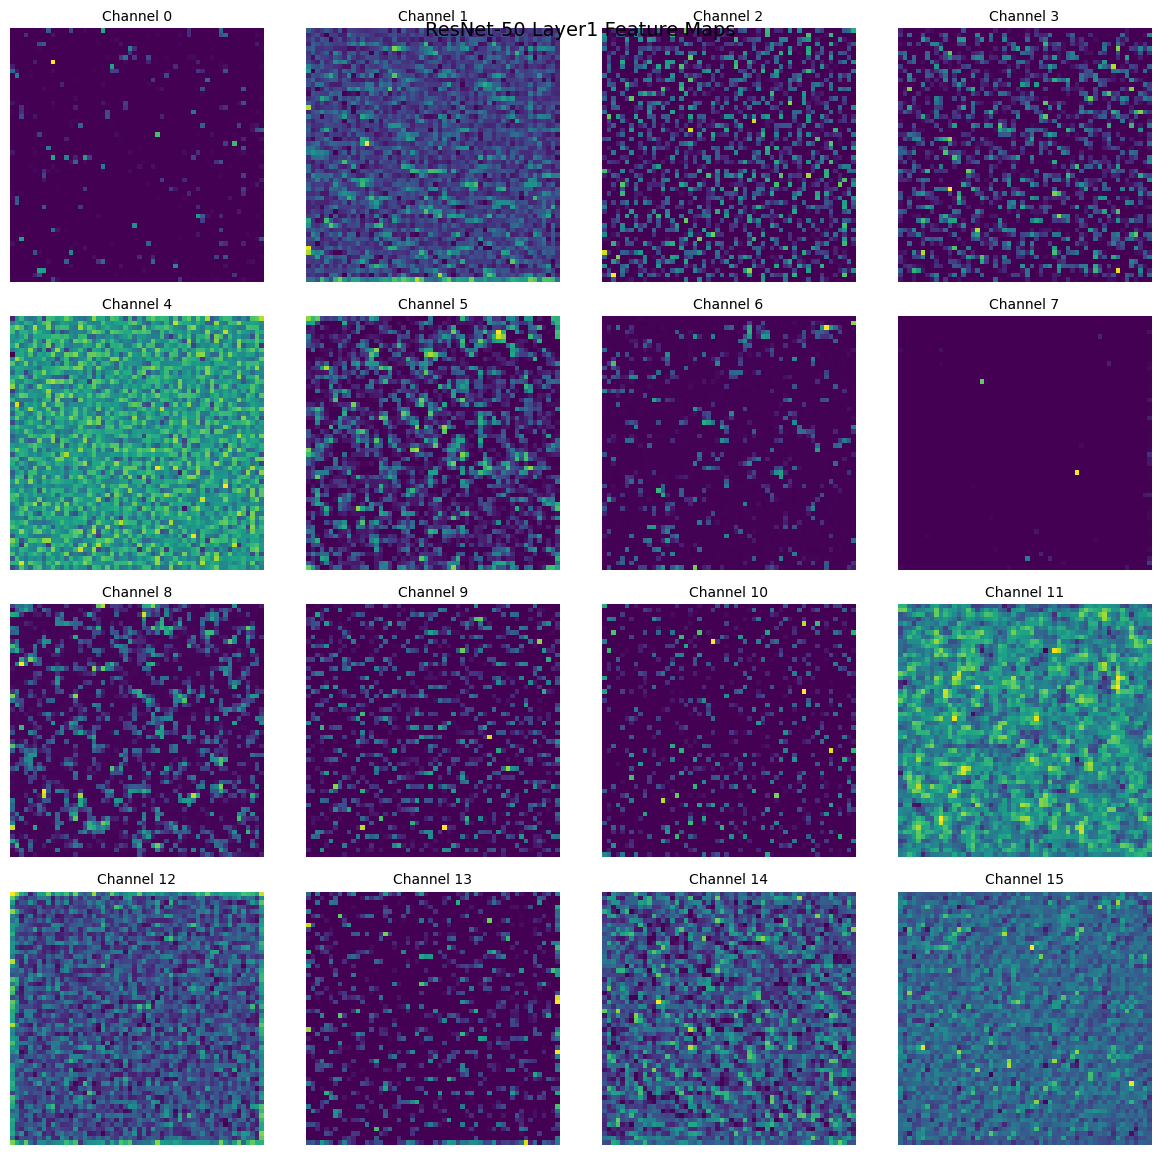

✅ 特征图可视化完成，结果已保存为 feature_maps.pdf


In [33]:
# 取出单样本的layer1特征图，维度为 (通道数, 高度, 宽度)
fmap = feature_maps['layer1'][0]

# 创建4×4子图布局，可视化前16个通道
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < fmap.shape[0]:
        ax.imshow(fmap[i].cpu().numpy(), cmap='viridis')
        ax.set_title(f'Channel {i}', fontsize=10)
    ax.axis('off')

plt.suptitle('ResNet-50 Layer1 Feature Maps', fontsize=14, y=0.95)
plt.tight_layout()

# 保存高清矢量图并展示结果
plt.savefig('feature_maps.pdf', dpi=150, bbox_inches='tight')
plt.show()

# 移除注册的钩子，避免后续操作产生额外开销
hook.remove()
print("✅ 特征图可视化完成，结果已保存为 feature_maps.pdf")

**步骤 7：迁移学习实现方法说明**

基于预训练 ResNet 模型的迁移学习分为两种主流方案，可根据数据集规模与任务相似度灵活选择：  
1.特征提取法  
冻结 Backbone 全部参数，仅替换并训练最后的全连接分类头
适用于小数据集、任务与 ImageNet 相似度高的场景，训练速度快、不易过拟合  
2.微调法（Fine-tuning）  
解冻部分或全部网络层，使用任务数据以较小学习率更新权重
适用于数据量充足、任务与 ImageNet 差异较大的场景，模型上限更高

In [37]:
# 替换分类头：将原1000类输出改为自定义类别数（示例为10类）
num_classes = 10
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)

# 特征提取模式：冻结Backbone所有参数
for param in model.parameters():
    param.requires_grad = False
# 仅分类头参数参与梯度更新
for param in model.fc.parameters():
    param.requires_grad = True